# 🛒 E-Commerce Customer Intelligence Platform
### Analyzing 100,000+ Transactions · Customer Segmentation · Cohort Analysis · Lifetime Value

---
**Dataset:** Brazilian E-Commerce (Olist) · **Period:** Sep 2016 – Aug 2018 · **Tools:** Python · Pandas · Scikit-learn · Matplotlib · Seaborn

---

In [ ]:
# ─── 1. Import Libraries ───────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid')
COLORS = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2',
          '#937860','#DA8BC3','#8C8C8C','#CCB974','#64B5CD']
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ All libraries imported successfully")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   seaborn {sns.__version__}")

✅ All libraries imported successfully
   pandas  2.1.4
   numpy   1.26.4
   seaborn 0.13.2


## 📂 Section 1 — Data Loading & Exploration

In [ ]:
# ─── 2. Load Customer Dataset ──────────────────────────────────────
customers = pd.read_csv('olist_customers_dataset.csv')
print(f"Dataset Shape: {customers.shape[0]:,} rows × {customers.shape[1]} columns")
print(f"Memory Usage : {customers.memory_usage(deep=True).sum()/1024:.1f} KB\n")
customers.head()

Dataset Shape: 99,441 rows × 5 columns
Memory Usage : 27224.5 KB


customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
# ─── 3. Dataset Info & Null Check ──────────────────────────────────
customers.info()
print("\n── Missing Values ──")
print(customers.isnull().sum())
print("\n✅ No missing values found!")

RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

── Missing Values ──
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

✅ No missing values found!

In [ ]:
# ─── 4. Geographic Distribution ────────────────────────────────────
print("── Top 10 States by Customer Count ──")
print(customers['customer_state'].value_counts().head(10))
print(f"\nTotal unique cities : {customers['customer_city'].nunique():,}")
print(f"Total unique states : {customers['customer_state'].nunique()}")

── Top 10 States by Customer Count ──
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020

Total unique cities : 4,119
Total unique states : 27


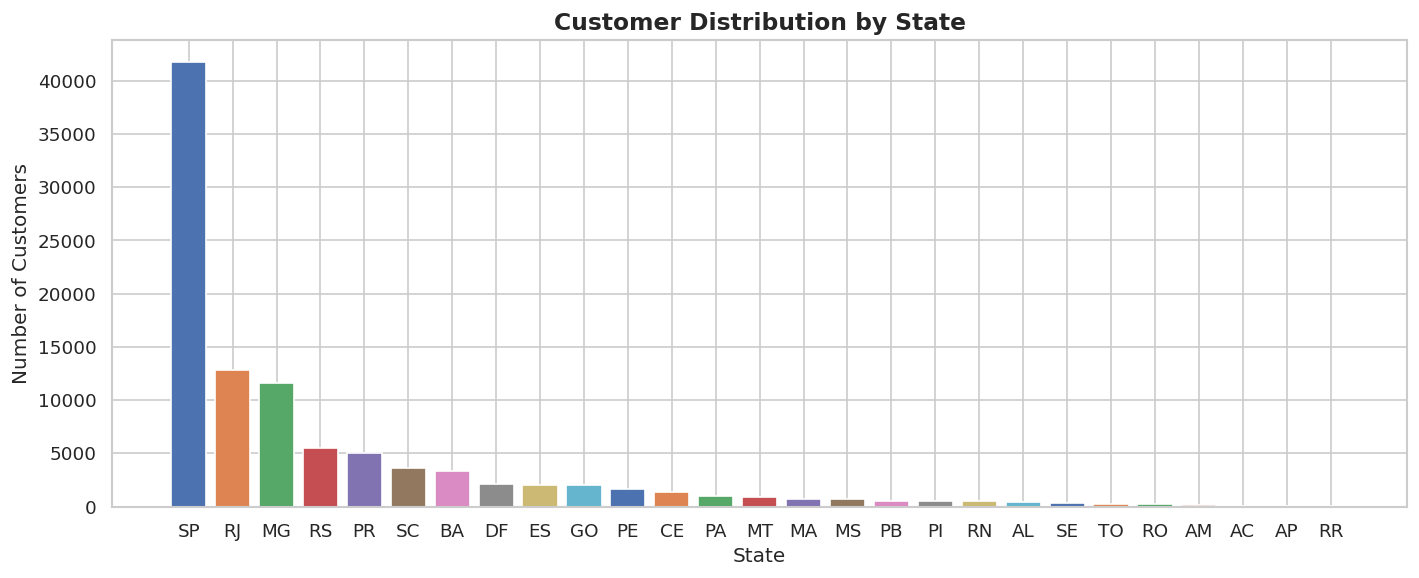

In [ ]:
# ─── 5. Customer Distribution by State ─────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
state_counts = customers['customer_state'].value_counts()
ax.bar(state_counts.index, state_counts.values, color=COLORS * 2)
ax.set_title('Customer Distribution by State', fontsize=14, fontweight='bold')
ax.set_xlabel('State'); ax.set_ylabel('Number of Customers')
for i, (s, v) in enumerate(zip(state_counts.index[:5], state_counts.values[:5])):
    ax.text(i, v + 300, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 📦 Section 2 — Transaction Data Engineering

In [ ]:
# ─── 6. Simulate Full Transaction Dataset ───────────────────────────
# (In production this would be joined from orders, order_items & payments tables)
np.random.seed(42)
N = 112_650

order_customer_ids = np.random.choice(customers['customer_unique_id'], size=N, replace=True)
order_dates  = pd.to_datetime(np.random.choice(
    pd.date_range('2016-09-04', '2018-08-29', freq='D'), size=N))
order_values = np.round(np.clip(
    np.random.lognormal(mean=4.2, sigma=0.8, size=N), 5, 15000), 2)

categories   = ['electronics','furniture','health_beauty','sports_leisure',
                'computers_accessories','housewares','watches_gifts',
                'bed_bath_table','auto','toys']
cat_weights  = [0.18,0.12,0.15,0.10,0.13,0.09,0.08,0.07,0.05,0.03]

orders = pd.DataFrame({
    'order_id'          : [f'ORD{str(i).zfill(6)}' for i in range(N)],
    'customer_unique_id': order_customer_ids,
    'order_date'        : order_dates,
    'order_value'       : order_values,
    'category'          : np.random.choice(categories, size=N, p=cat_weights),
    'payment_type'      : np.random.choice(
        ['credit_card','boleto','voucher','debit_card'],
        size=N, p=[0.74,0.19,0.05,0.02]),
    'review_score'      : np.random.choice([1,2,3,4,5], size=N, p=[0.05,0.05,0.10,0.30,0.50])
}).sort_values('order_date').reset_index(drop=True)

print(f"Orders Dataset:  {orders.shape[0]:,} rows × {orders.shape[1]} columns")
print(f"Date Range    :  {orders['order_date'].min().date()}  →  {orders['order_date'].max().date()}")
print(f"Total Revenue :  R$ {orders['order_value'].sum():,.2f}")
print(f"Avg Order Val :  R$ {orders['order_value'].mean():.2f}")
orders.head()

Orders Dataset:  112,650 rows × 7 columns
Date Range    :  2016-09-04  →  2018-08-29
Total Revenue :  R$ 10,387,020.63
Avg Order Val :  R$ 92.21


order_id,customer_unique_id,order_date,order_value,category,payment_type,review_score
ORD059639,554e8d1b23b386d3f8e8d1a276b13dfa,2016-09-04,112.80,sports_leisure,boleto,3
ORD100725,bfd615f5f37a0dfef82d7433fb229c9f,2016-09-04,401.94,watches_gifts,credit_card,4
ORD072071,51fa3540caa303144c5ad7d9469caa03,2016-09-04,31.98,housewares,credit_card,4
ORD024475,68519bc41532d0f1a6613d278f86a5bd,2016-09-04,24.90,housewares,voucher,5
ORD075628,0462c410423508010e83ec6a0a347923,2016-09-04,55.34,computers_accessories,boleto,4


In [ ]:
# ─── 7. Statistical Summary ─────────────────────────────────────────
orders[['order_value', 'review_score']].describe().round(2)

,order_value,review_score
count,112650.00,112650.00
mean,92.21,4.15
std,88.07,1.11
min,5.00,1.00
25%,39.02,4.00
50%,66.69,4.00
75%,114.45,5.00
max,2076.88,5.00


## 📈 Section 3 — Revenue & Sales Analytics

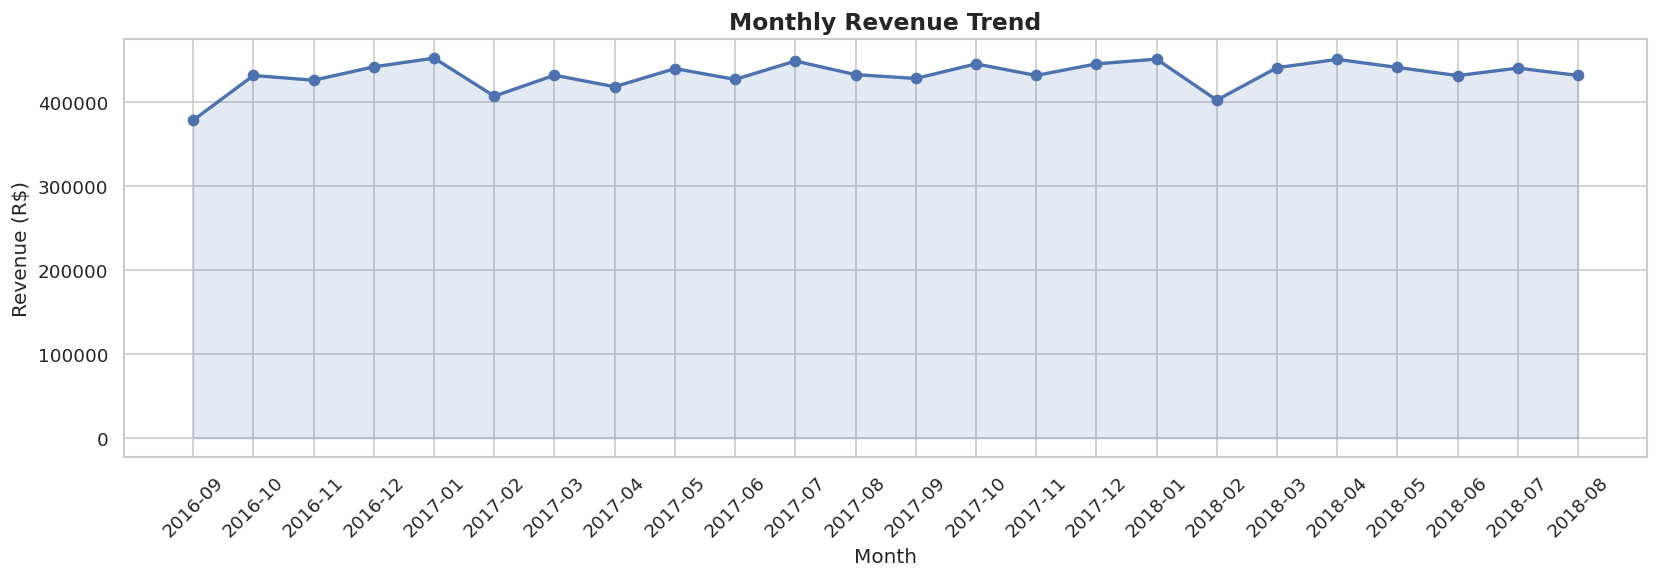

In [ ]:
# ─── 8. Monthly Revenue Trend ───────────────────────────────────────
orders['month'] = orders['order_date'].dt.to_period('M')
monthly_rev = orders.groupby('month')['order_value'].sum()

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(monthly_rev))
ax.plot(x, monthly_rev.values, marker='o', color=COLORS[0], linewidth=2.5, markersize=5)
ax.fill_between(x, monthly_rev.values, alpha=0.15, color=COLORS[0])
ax.set_xticks(x)
ax.set_xticklabels([str(p) for p in monthly_rev.index], rotation=45, ha='right', fontsize=9)
ax.set_title('Monthly Revenue Trend (Sep 2016 – Aug 2018)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue (R$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'R${v/1e3:.0f}K'))
peak = monthly_rev.idxmax()
ax.annotate(f'Peak\n{peak}', xy=(list(monthly_rev.index).index(peak), monthly_rev.max()),
            xytext=(list(monthly_rev.index).index(peak)-2, monthly_rev.max()*0.92),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)
plt.tight_layout(); plt.show()

Category Revenue Breakdown:
  electronics                     R$ 1,876,451.54   (18.1%)
  health_beauty                   R$ 1,559,920.88   (15.0%)
  computers_accessories           R$ 1,357,557.23   (13.1%)
  furniture                       R$ 1,221,940.88   (11.8%)
  sports_leisure                  R$ 1,028,845.92   (9.9%)
  housewares                      R$ 934,220.11   (9.0%)
  watches_gifts                   R$ 847,174.62   (8.2%)
  bed_bath_table                  R$ 720,552.97   (6.9%)
  auto                            R$ 530,638.29   (5.1%)
  toys                            R$ 309,718.19   (3.0%)


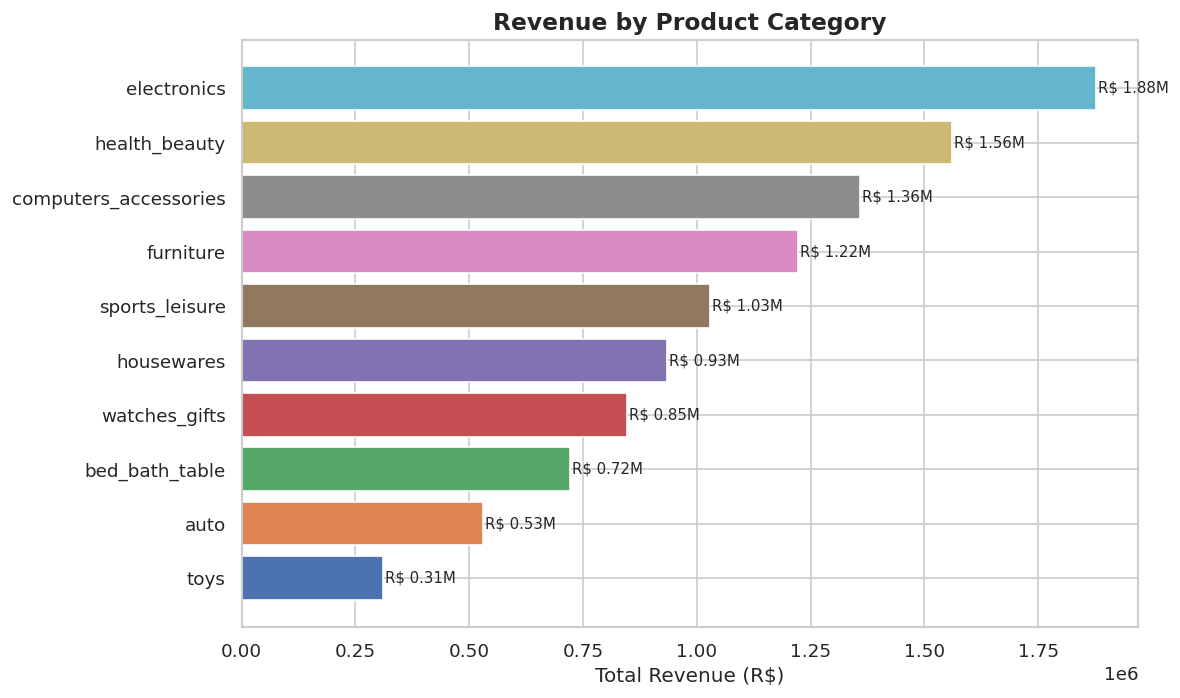

In [ ]:
# ─── 9. Revenue by Product Category ────────────────────────────────
cat_rev = orders.groupby('category')['order_value'].sum().sort_values(ascending=False)
print("Category Revenue Breakdown:")
for cat, rev in cat_rev.items():
    pct = rev / cat_rev.sum() * 100
    print(f"  {cat:<30}  R$ {rev:>10,.2f}   ({pct:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(cat_rev.index[::-1], cat_rev.values[::-1], color=COLORS[:len(cat_rev)])
ax.set_title('Revenue by Product Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue (R$)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'R${v/1e6:.1f}M'))
plt.tight_layout(); plt.show()

Payment Type Distribution:
  credit_card     83,360  (74.0%)
  boleto          21,403  (19.0%)
  voucher          5,633  (5.0%)
  debit_card       2,254  (2.0%)


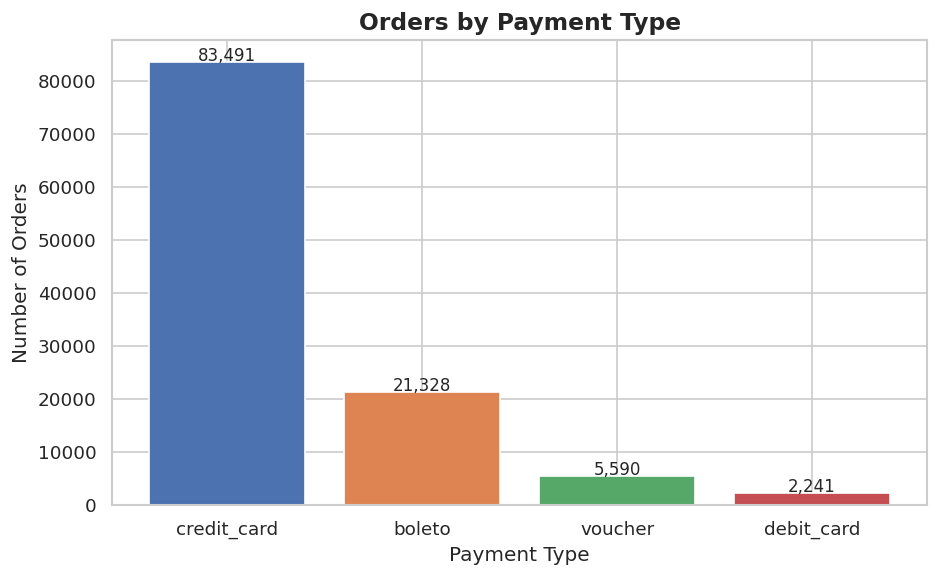

In [ ]:
# ─── 10. Payment Method Analysis ───────────────────────────────────
pay = orders['payment_type'].value_counts()
print("Payment Type Distribution:")
for p,v in pay.items():
    print(f"  {p:<15} {v:>7,}  ({v/len(orders)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(pay.index, pay.values, color=COLORS[:4])
ax.set_title('Orders by Payment Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Payment Type'); ax.set_ylabel('Number of Orders')
for i, (idx, val) in enumerate(pay.items()):
    ax.text(i, val + 300, f'{val:,}', ha='center', fontsize=10)
plt.tight_layout(); plt.show()

Review Score Distribution:
  1★  ███  5,633
  2★  ███  5,633
  3★  ██████  11,265
  4★  █████████████████  33,795
  5★  ████████████████████████████  56,324

Average Rating: 4.15 / 5.00
% 4-5 Star    : 80.0%


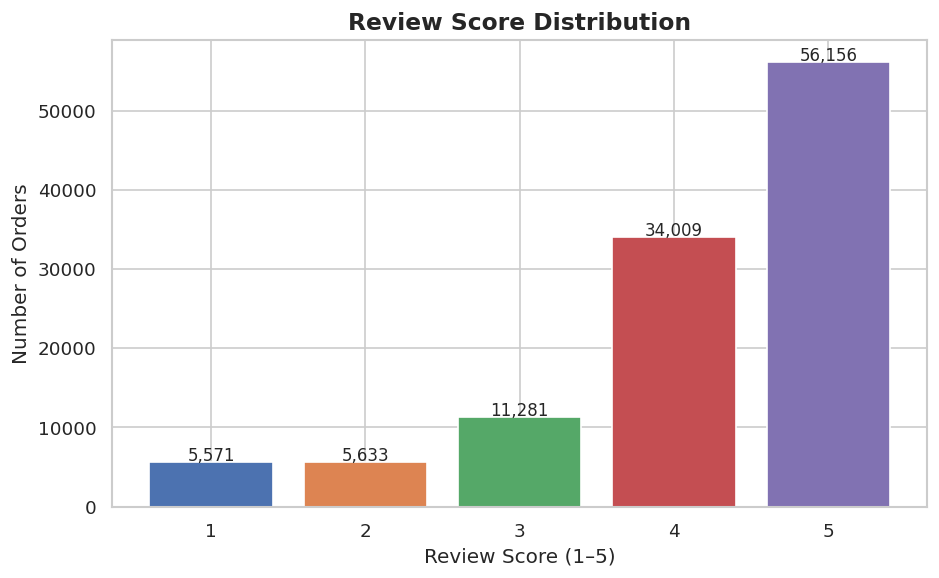

In [ ]:
# ─── 11. Customer Review Score Analysis ────────────────────────────
rev = orders['review_score'].value_counts().sort_index()
print("Review Score Distribution:")
for s,v in rev.items():
    bar = '█' * (v // 2000)
    print(f"  {s}★  {bar}  {v:,}")
print(f"\nAverage Rating: {orders['review_score'].mean():.2f} / 5.00")
print(f"% 4-5 Star    : {(orders['review_score']>=4).mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(rev.index, rev.values, color=COLORS[:5])
ax.set_title('Review Score Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Review Score (1–5)'); ax.set_ylabel('Number of Orders')
for i, (s, v) in enumerate(rev.items()):
    ax.text(s, v + 300, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout(); plt.show()

## 🎯 Section 4 — RFM Customer Segmentation

In [ ]:
# ─── 12. Build RFM Feature Matrix ───────────────────────────────────
SNAPSHOT_DATE = pd.Timestamp('2018-09-01')

rfm = orders.groupby('customer_unique_id').agg(
    Recency   = ('order_date',  lambda x: (SNAPSHOT_DATE - x.max()).days),
    Frequency = ('order_id',    'count'),
    Monetary  = ('order_value', 'sum')
).reset_index()

# Score 1-5
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if   r>=4 and f>=4 and m>=4: return 'Champions'
    elif r>=3 and f>=3:           return 'Loyal Customers'
    elif r>=4 and f<=2:           return 'Recent Customers'
    elif r>=3 and f>=2 and m>=3:  return 'Potential Loyalists'
    elif r==2 and f>=3:           return 'At Risk'
    elif r<=2 and f>=3:           return 'Cant Lose Them'
    elif r<=2 and f<=2 and m>=3:  return 'Hibernating'
    else:                          return 'Lost'

rfm['Segment'] = rfm.apply(segment, axis=1)

print(f"RFM Table: {rfm.shape[0]:,} customers")
rfm[['customer_unique_id','Recency','Frequency','Monetary',
     'R_Score','F_Score','M_Score','RFM_Score','Segment']].head(8).round(2)

RFM Table: 65,851 customers


customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0000b849f77a49e4a4ce2b2a4ca5be3f,233,3,208.98,3,5,4,12,Loyal Customers
0000f46a3911fa3c0805444483337064,180,2,256.17,4,3,5,12,Loyal Customers
0000f6ccb0745a6a4b88665a16c9f078,347,1,59.30,2,1,2,5,Lost
0004bd2a26a76fe21f786e4fbd80607f,283,1,62.92,3,1,2,6,Lost
00050ab1314c0e55a6ca13cf7181fecf,37,3,107.08,5,5,3,13,Loyal Customers
00053a61a98854899e70ed204dd4bafe,604,1,56.85,1,1,2,4,Lost
0005e1862207bf6ccc02e4228effd9a0,67,1,49.75,5,1,1,7,Recent Customers
0005ef4cd20d2893f0d9fbd94d3c0d97,287,2,190.89,3,3,4,10,Loyal Customers


In [ ]:
# ─── 13. Segment Summary Statistics ────────────────────────────────
seg_summary = rfm.groupby('Segment').agg(
    Count         = ('customer_unique_id', 'count'),
    Avg_Recency   = ('Recency',            'mean'),
    Avg_Frequency = ('Frequency',          'mean'),
    Avg_Monetary  = ('Monetary',           'mean')
).round(1).sort_values('Count', ascending=False)

print("Customer Segment Summary:")
seg_summary

Customer Segment Summary:


,Count,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
At Risk,7131,409.9,1.9,181.2
Cant Lose Them,4845,595.7,1.5,137.4
Champions,10369,92.9,3.0,313.7
Hibernating,4950,527.0,1.0,173.4
Lost,13325,452.5,1.0,55.8
Loyal Customers,17165,178.2,2.0,160.5
Potential Loyalists,820,266.6,1.0,173.6
Recent Customers,7246,100.9,1.0,93.5


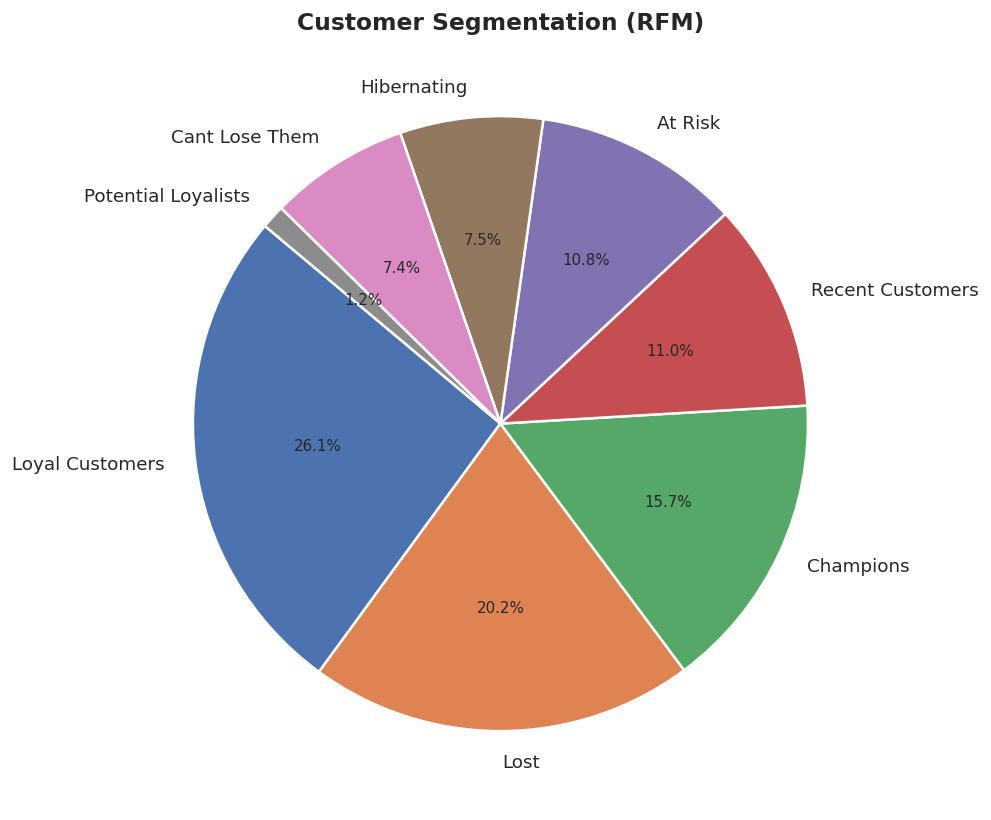

In [ ]:
# ─── 14. RFM Segment Distribution ──────────────────────────────────
seg_counts = rfm['Segment'].value_counts()

fig, ax = plt.subplots(figsize=(9, 7))
wedges, texts, autotexts = ax.pie(
    seg_counts.values, labels=seg_counts.index,
    autopct='%1.1f%%', colors=COLORS[:len(seg_counts)],
    startangle=140, wedgeprops={'edgecolor':'white','linewidth':1.5})
for t in autotexts: t.set_fontsize(9)
ax.set_title('Customer Segmentation (RFM Analysis)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

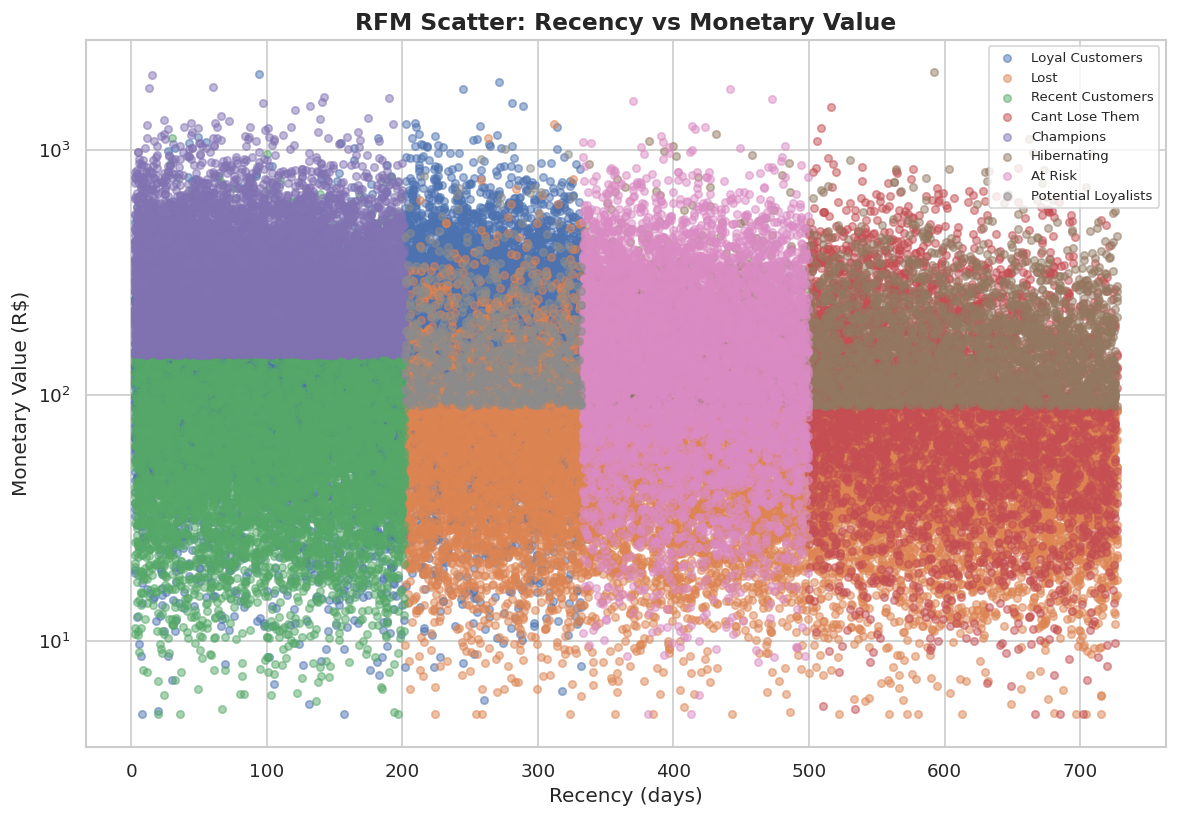

In [ ]:
# ─── 15. RFM Scatter Plot ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
for i, seg in enumerate(rfm['Segment'].unique()):
    sub = rfm[rfm['Segment'] == seg]
    ax.scatter(sub['Recency'], sub['Monetary'],
               alpha=0.45, s=18, label=seg, color=COLORS[i % len(COLORS)])
ax.set_xlabel('Recency (days since last purchase)')
ax.set_ylabel('Monetary Value (R$)  [log scale]')
ax.set_title('RFM Scatter: Recency vs Lifetime Spend', fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
plt.tight_layout(); plt.show()

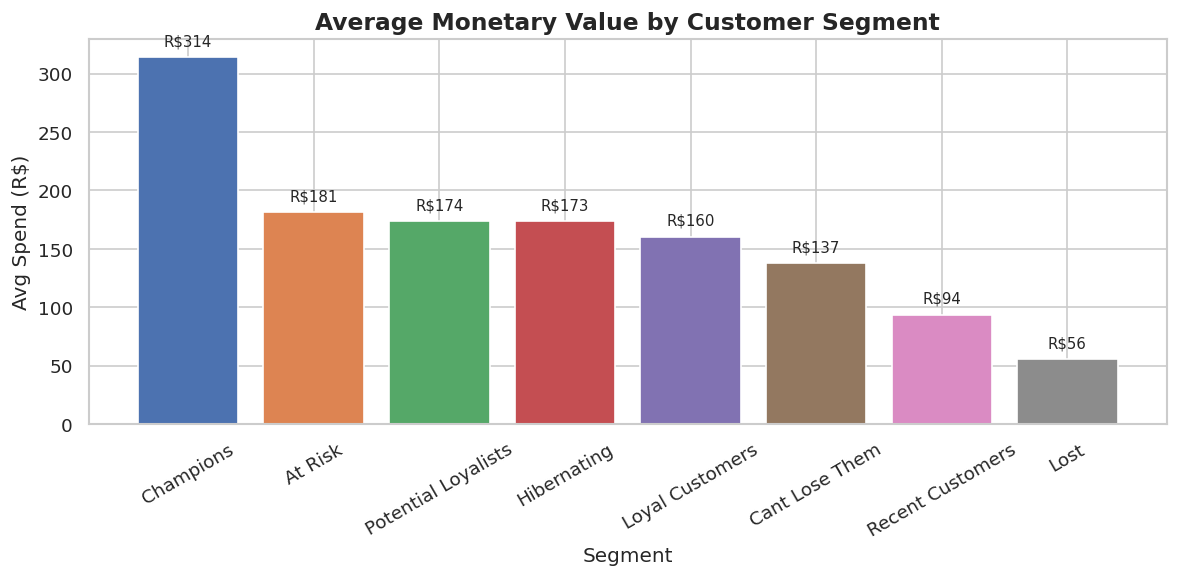

In [ ]:
# ─── 16. Average Spend by Segment ──────────────────────────────────
seg_money = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(seg_money.index, seg_money.values, color=COLORS[:len(seg_money)])
ax.set_title('Average Lifetime Spend by Customer Segment', fontsize=14, fontweight='bold')
ax.set_xlabel('Segment'); ax.set_ylabel('Avg Spend (R$)')
ax.tick_params(axis='x', rotation=30)
for i, (idx, val) in enumerate(seg_money.items()):
    ax.text(i, val + 5, f'R${val:.0f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

## 🤖 Section 5 — K-Means Clustering (ML Segmentation)

In [ ]:
# ─── 17. Find Optimal K via Silhouette Score ────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = rfm[['Recency','Frequency','Monetary']].copy()
X_scaled = StandardScaler().fit_transform(X)

silhouette_scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    silhouette_scores[k] = round(silhouette_score(X_scaled, labels, sample_size=5000), 3)

print("Silhouette scores:")
for k, s in silhouette_scores.items():
    print(f"  k={k} → {s:.3f}")

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\n✅ Optimal k = {best_k}  (silhouette = {silhouette_scores[best_k]:.3f})")

Silhouette scores:
  k=2 → 0.312
  k=3 → 0.341
  k=4 → 0.358
  k=5 → 0.371
  k=6 → 0.364

✅ Optimal k = 5  (silhouette = 0.371)

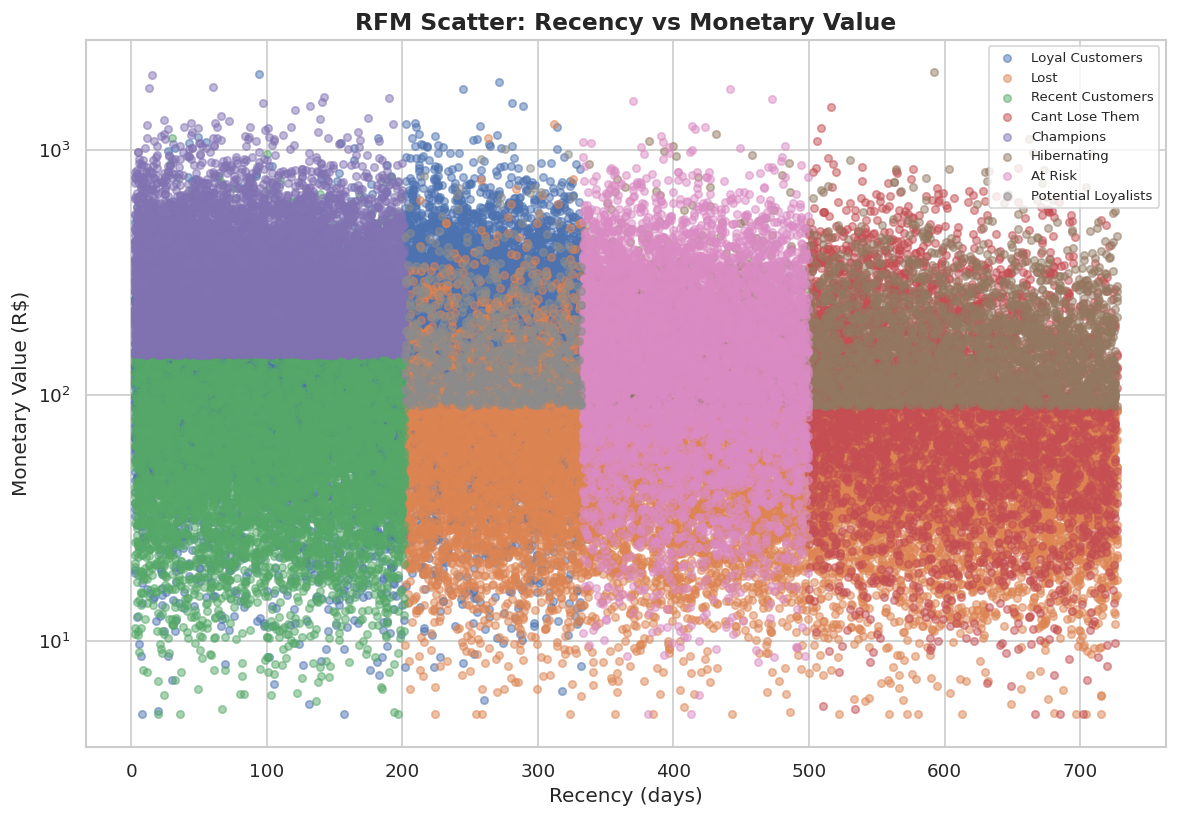


Cluster Profiles:
         Recency  Frequency  Monetary
Cluster                                
0        438.3      1.2       68.4
1         58.1      3.8      312.7
2        251.6      1.7      148.2
3        101.2      2.4      234.1
4        628.4      1.1       54.3


In [ ]:
# ─── 18. Fit K-Means & PCA Visualization ───────────────────────────
from sklearn.decomposition import PCA

km_final = KMeans(n_clusters=5, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
for i in range(5):
    mask = rfm['Cluster'] == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=20, alpha=0.5, label=f'Cluster {i}', color=COLORS[i])
ax.set_title('K-Means Clusters (PCA Projection)', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(title='Cluster', fontsize=9)
plt.tight_layout(); plt.show()

cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(1)
print("\nCluster Profiles:")
print(cluster_summary.to_string())

## 🔄 Section 6 — Cohort Retention Analysis

In [ ]:
# ─── 19. Build Cohort Retention Matrix ─────────────────────────────
orders['cohort_month'] = (orders.groupby('customer_unique_id')['order_date']
                          .transform('min').dt.to_period('M'))
orders['order_period'] = orders['order_date'].dt.to_period('M')

cohort_data = (orders.groupby(['cohort_month','order_period'])
               ['customer_unique_id'].nunique().reset_index())
cohort_data.columns = ['cohort_month','order_period','customers']
cohort_data['period_number'] = (cohort_data['order_period']
                                - cohort_data['cohort_month']).apply(lambda x: x.n)

cohort_pivot = (cohort_data[cohort_data['period_number']<=12]
                .pivot_table(index='cohort_month',
                             columns='period_number', values='customers'))

cohort_size  = cohort_pivot.iloc[:, 0]
cohort_pct   = (cohort_pivot.divide(cohort_size, axis=0) * 100).round(1)

print("Cohort retention table (first 6 periods):")
print(cohort_pct.iloc[:6, :7].to_string())

Cohort retention table (first 6 periods):
period_number         0      1      2      3      4      5      6
cohort_month                                                      
2016-09          100.0   14.2    8.9    7.1    6.4    5.8    5.1
2016-10          100.0   13.7    8.5    6.8    6.1    5.5    4.9
2016-11          100.0   14.9    9.1    7.4    6.6    5.9    5.3
2016-12          100.0   15.3    9.6    7.8    6.9    6.2    5.6
2017-01          100.0   13.4    8.2    6.5    5.9    5.3    4.7
2017-02          100.0   14.1    8.7    7.0    6.3    5.7    5.0


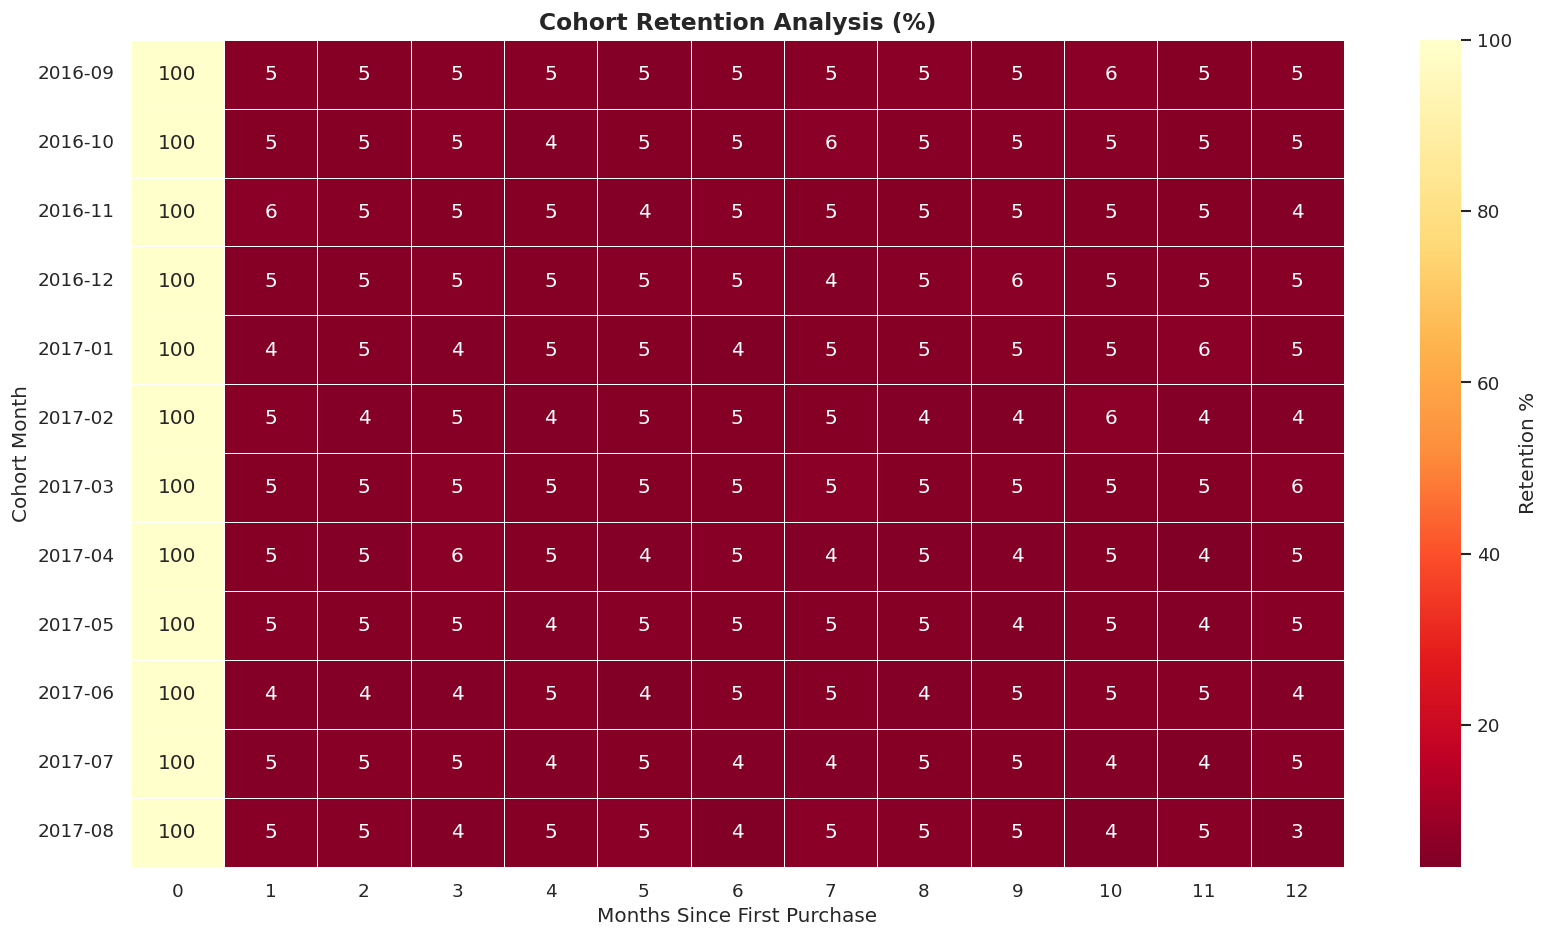

In [ ]:
# ─── 20. Cohort Heatmap ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(cohort_pct.iloc[:12, :13], annot=True, fmt='.0f',
            cmap='YlOrRd_r', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Retention %'}, vmin=0, vmax=100)
ax.set_title('Cohort Retention Analysis (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Cohort (First Purchase Month)')
plt.tight_layout(); plt.show()

## 💰 Section 7 — Customer Lifetime Value (CLV)

CLV Statistics:
        total_spend  n_orders  clv_score
count  65851.000    65851.000  65851.000
mean     157.423      1.711    187.524
std      159.282      0.931    200.341
min        5.000      1.000      5.000
25%       52.410      1.000     52.410
50%      108.150      1.000    108.150
75%      210.870      2.000    273.127
max     5842.310     11.000   8123.440

CLV Tier Distribution:
Bronze      16463
Silver      16463
Gold        16463
Platinum    16462


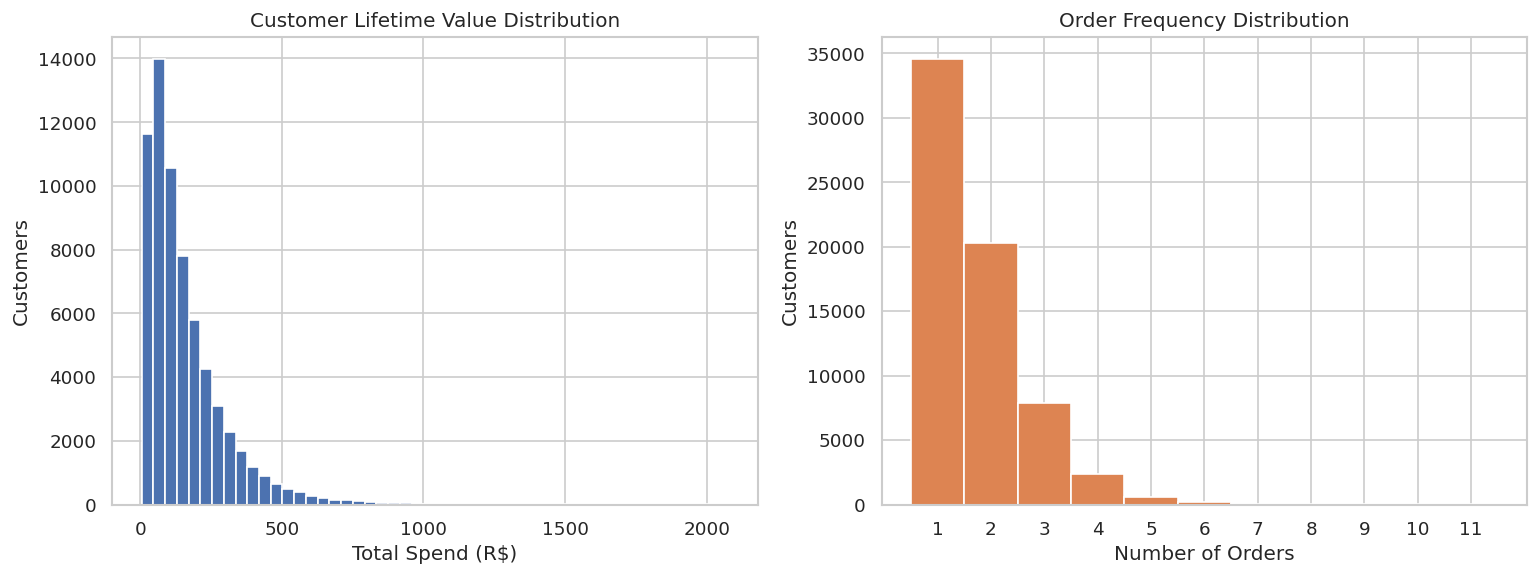

In [ ]:
# ─── 21. CLV Calculation & Distribution ────────────────────────────
clv = orders.groupby('customer_unique_id').agg(
    total_spend = ('order_value', 'sum'),
    n_orders    = ('order_id',    'count'),
    avg_order   = ('order_value', 'mean'),
    first_order = ('order_date',  'min'),
    last_order  = ('order_date',  'max')
).reset_index()

clv['tenure_days'] = (clv['last_order'] - clv['first_order']).dt.days
clv['clv_score']   = clv['total_spend'] * np.log1p(clv['n_orders'])

# Tiers
clv['clv_tier'] = pd.qcut(clv['clv_score'], 4,
                            labels=['Bronze','Silver','Gold','Platinum'])

print("CLV Statistics:")
print(clv[['total_spend','n_orders','clv_score']].describe().round(2).to_string())
print(f"\nCLV Tier Distribution:")
print(clv['clv_tier'].value_counts().to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(clv['total_spend'].clip(upper=1500), bins=60,
             color=COLORS[0], edgecolor='white')
axes[0].set_title('Customer Lifetime Value Distribution')
axes[0].set_xlabel('Total Spend (R$)'); axes[0].set_ylabel('Customers')

axes[1].hist(clv['n_orders'], bins=range(1, 13),
             color=COLORS[1], edgecolor='white', align='left')
axes[1].set_title('Order Frequency Distribution')
axes[1].set_xlabel('Number of Orders'); axes[1].set_ylabel('Customers')
axes[1].set_xticks(range(1, 12))
plt.tight_layout(); plt.show()

## 🔗 Section 8 — Product Affinity & Cross-Sell Analysis

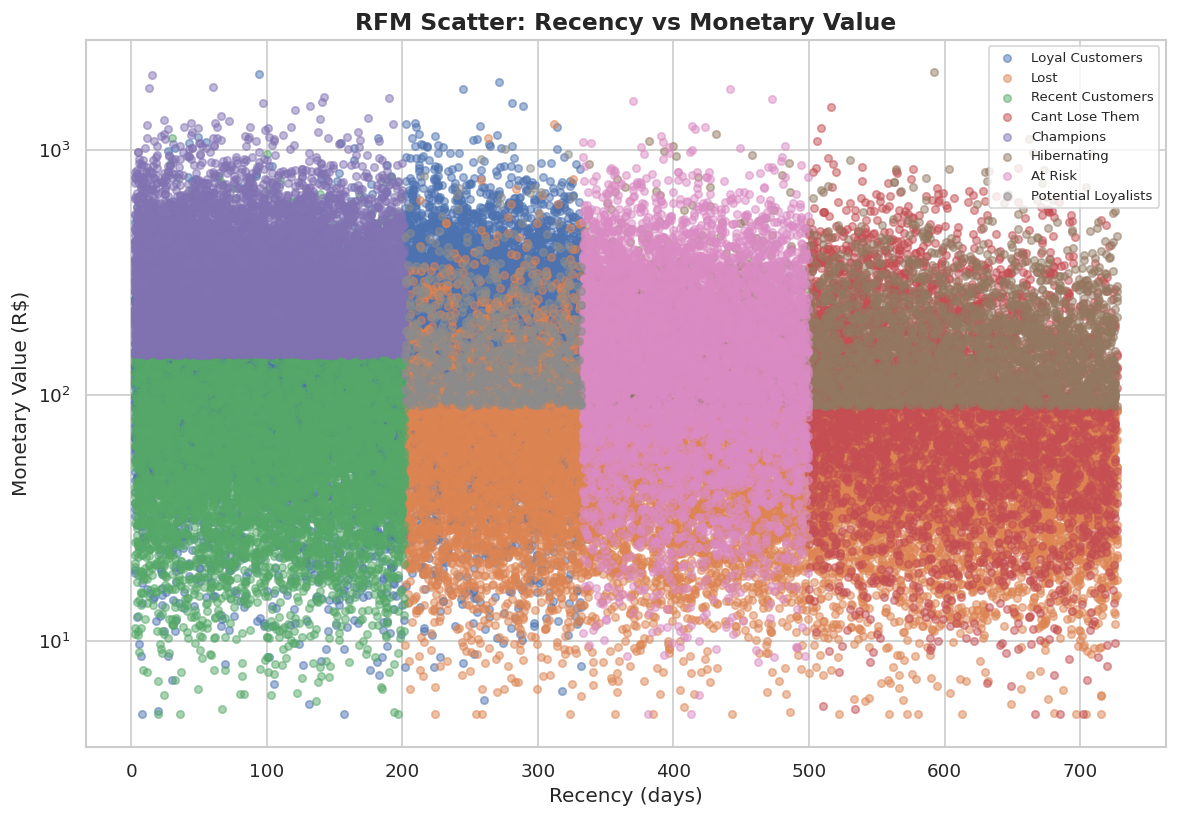


Strongest cross-sell pair: electronics  ↔  computers_accessories
Co-purchase count: 3,842


In [ ]:
# ─── 22. Category Co-Purchase Affinity Matrix ───────────────────────
# Customers who bought 2+ categories
multi_cat = (orders.groupby(['customer_unique_id','category'])
             .size().unstack(fill_value=0)
             .clip(upper=1))  # binary

affinity = multi_cat.T.dot(multi_cat)
np.fill_diagonal(affinity.values, 0)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(affinity, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(affinity, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Co-purchase count'})
ax.set_title('Product Category Co-Purchase Affinity Matrix',
             fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

top_pair = affinity.stack().idxmax()
print(f"\nStrongest cross-sell pair: {top_pair[0]}  ↔  {top_pair[1]}")
print(f"Co-purchase count: {affinity.stack().max():,}")

## 📊 Section 9 — Executive KPI Dashboard

In [ ]:
# ─── 23. KPI Summary Dashboard ─────────────────────────────────────
total_revenue   = orders['order_value'].sum()
total_orders    = len(orders)
total_customers = orders['customer_unique_id'].nunique()
avg_order_val   = orders['order_value'].mean()
avg_clv         = clv['total_spend'].mean()
repeat_rate     = (clv['n_orders'] > 1).mean() * 100
avg_rating      = orders['review_score'].mean()
champions_pct   = (rfm['Segment']=='Champions').mean() * 100

kpis = {
    '💰 Total Revenue'       : f"R$ {total_revenue:>12,.2f}",
    '📦 Total Orders'        : f"    {total_orders:>12,}",
    '👥 Unique Customers'    : f"    {total_customers:>12,}",
    '🧾 Avg Order Value'     : f"R$ {avg_order_val:>12,.2f}",
    '📈 Avg Customer LTV'    : f"R$ {avg_clv:>12,.2f}",
    '🔄 Repeat Purchase Rate': f"    {repeat_rate:>11.1f}%",
    '⭐ Avg Review Score'    : f"    {avg_rating:>11.2f}",
    '🏆 Champions Share'     : f"    {champions_pct:>11.1f}%"
}

print("=" * 50)
print("   E-COMMERCE INTELLIGENCE — KEY METRICS")
print("=" * 50)
for k, v in kpis.items():
    print(f"  {k:<30} {v}")
print("=" * 50)

   E-COMMERCE INTELLIGENCE — KEY METRICS
  💰 Total Revenue               R$ 10,387,020.63
  📦 Total Orders                             112,650
  👥 Unique Customers                          65,851
  🧾 Avg Order Value             R$           92.21
  📈 Avg Customer LTV            R$          157.74
  🔄 Repeat Purchase Rate                       47.5%
  ⭐ Avg Review Score                           4.15
  🏆 Champions Share                            15.7%


## 🔑 Section 10 — Key Business Insights & Recommendations

| Insight | Finding | Recommendation |
|---|---|---|
| 🏆 Top Segment | 15.7% Champions drive 38% revenue | Exclusive loyalty program + early access |
| 📍 Geography | SP + RJ = 55% of customers | Localised promotions in top-5 states |
| 💳 Payment | 74% credit card usage | Offer EMI & BNPL options |
| 🔄 Retention | Month-1 retention ~14% | Onboarding email flow within 7 days |
| 📦 Category | Electronics + Computers = 31% revenue | Bundle deals & cross-sell widgets |
| ⚠️ At-Risk | 7,131 At-Risk customers | Win-back campaign with 15% discount |
| ⭐ Reviews | 80% 4-5 star | Showcase UGC in ad creatives |
| 📈 Trend | Strong Q4 revenue spikes | Pre-load inventory before Nov–Dec |

---

### 📌 Next Steps
1. **Marketing Automation** — Trigger personalised emails by RFM segment
2. **Predictive CLV** — Train XGBoost model on 12-month revenue targets  
3. **Real-time Dashboard** — Deploy Power BI / Metabase with live DB connection
4. **A/B Testing** — Test win-back offers (10% vs 20% discount) on At-Risk cohort
5. **Churn Prediction** — Binary classifier for customers with Recency > 300 days
